# **Step 0: Installing Required Library and Importing it**

In [1]:
!pip install nltk

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# **Step 1: Ensures stopwords corpus is available for text preprocessing**


In [3]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

# **Step 2: Import the Dataset**

In [4]:
fake = pd.read_csv("/content/Fake.csv")
true = pd.read_csv("/content/True.csv")

# **Step 3: Data Understanding**

In [5]:
# Display first 5 rows of fake news dataset

fake.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
# Display first 5 rows of true news dataset

true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [7]:
# Display first 5 rows of true news dataset

true.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [8]:
# Display information about fake news dataset

fake.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23481 entries, 0 to 23480
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    23481 non-null  object
 1   text     23481 non-null  object
 2   subject  23481 non-null  object
 3   date     23481 non-null  object
dtypes: object(4)
memory usage: 733.9+ KB


In [9]:
# Display information about true news dataset

true.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21417 entries, 0 to 21416
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    21417 non-null  object
 1   text     21417 non-null  object
 2   subject  21417 non-null  object
 3   date     21417 non-null  object
dtypes: object(4)
memory usage: 669.4+ KB


In [10]:
# Check missing values in fake news dataset

fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [11]:
# Check missing values in true news dataset

true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [12]:
# Check duplicate rows in fake news dataset

fake.duplicated().sum()

np.int64(3)

In [13]:
# Check duplicate rows in true news dataset

true.duplicated().sum()

np.int64(206)

# **Step 4: Data Cleaning**

In [14]:
# Remove duplicate rows from fake dataset

fake = fake.drop_duplicates()

In [15]:
# Remove duplicate rows from true dataset

true = true.drop_duplicates()

In [16]:
# Reset index of fake dataset

fake.reset_index(drop=True, inplace=True)

In [17]:
# Reset index of true dataset

true.reset_index(drop=True, inplace=True)

In [18]:
# Check duplicate rows in fake dataset

fake.duplicated().sum()

np.int64(0)

In [19]:
# Check duplicate rows in true dataset

true.duplicated().sum()

np.int64(0)

In [20]:
# Check missing values in fake dataset

fake.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [21]:
# Check missing values in true dataset

true.isnull().sum()

,0
title,0
text,0
subject,0
date,0


In [22]:
# Add label for fake news

fake["label"] = 0

In [23]:
# Add label for true news

true["label"] = 1

In [24]:
# Combine fake and true datasets

df = pd.concat([fake, true], ignore_index=True)

In [25]:
# Shuffle the dataset

df = df.sample(frac=1, random_state=42)

df.reset_index(drop=True, inplace=True)

In [26]:
# Display first 5 rows

df.head()

,title,text,subject,date,label
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,"A school librarian in Cambridge, Massachusetts...",left-news,"Sep 28, 2017",0
1,Kenya opposition leader calls for calm in slum...,NAIROBI (Reuters) - Kenyan opposition leader R...,worldnews,"October 29, 2017",1
2,Egypt rejects U.S. decision to move its embass...,CAIRO (Reuters) - Egypt rejected the U.S. deci...,worldnews,"December 6, 2017",1
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,After a recent speech given by Minister Louis ...,left-news,"May 8, 2015",0
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,Tensions ran high outside of a campaign rally ...,News,"March 11, 2016",0


In [27]:
# Check dataset size

df.shape

(44689, 5)

In [28]:
# Check missing values

df.isnull().sum()

,0
title,0
text,0
subject,0
date,0
label,0


# **Step 5 : Exploratory Data Analysis (EDA)**

In [29]:
# Count fake and real news

df["label"].value_counts()

,count
label,
0,23478
1,21211


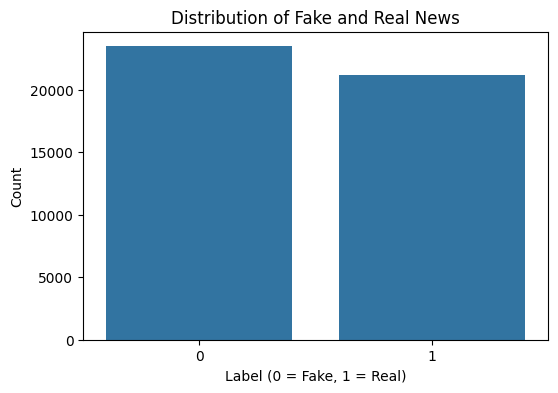

In [30]:
# Plot fake and real news distribution

plt.figure(figsize=(6,4))

sns.countplot(x="label", data=df)

plt.title("Distribution of Fake and Real News")

plt.xlabel("Label (0 = Fake, 1 = Real)")

plt.ylabel("Count")

plt.show()

In [31]:
# Display different news categories

df["subject"].value_counts()

,count
subject,
politicsNews,11220
worldnews,9991
News,9050
politics,6838
left-news,4459
Government News,1570
US_News,783
Middle-east,778


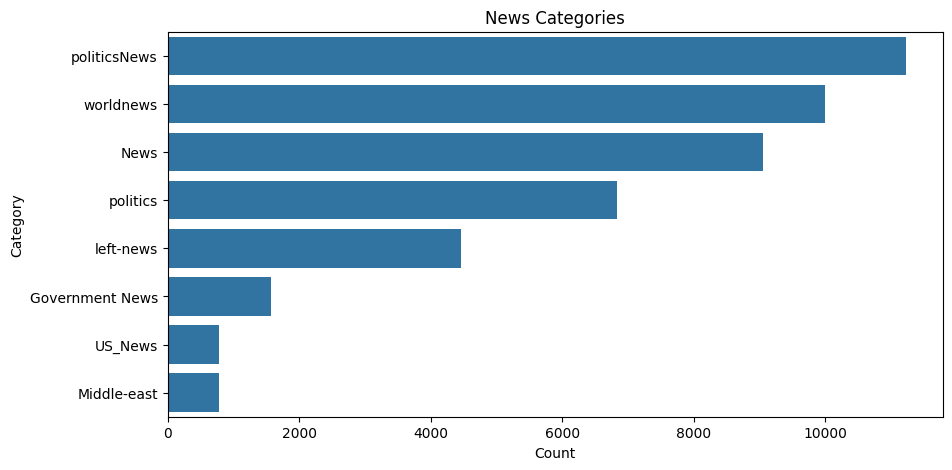

In [32]:
# Plot news categories

plt.figure(figsize=(10,5))

sns.countplot(y="subject", data=df, order=df["subject"].value_counts().index)

plt.title("News Categories")

plt.xlabel("Count")

plt.ylabel("Category")

plt.show()

In [33]:
# Count total words in each news article

df["word_count"] = df["text"].apply(lambda x: len(x.split()))

In [34]:
# Display first 5 rows

df[["word_count"]].head()

,word_count
0,1655
1,460
2,40
3,112
4,414


In [35]:
# Display summary of word count

df["word_count"].describe()

,word_count
count,44689.000000
mean,404.966502
std,351.573770
min,0.000000
25%,203.000000
50%,362.000000
75%,512.000000
max,8135.000000


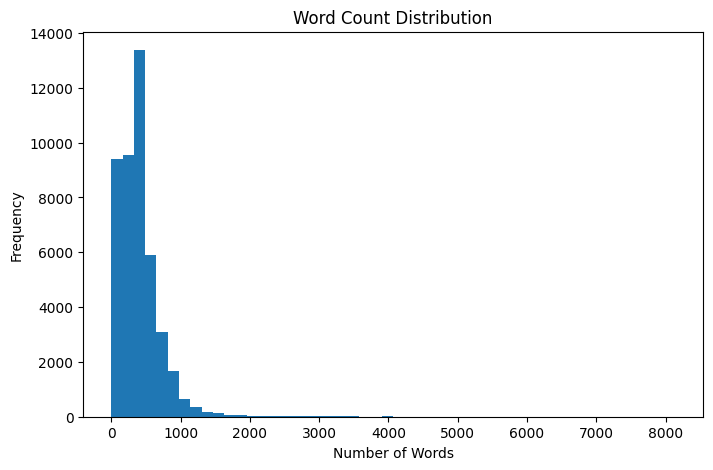

In [36]:
# Plot distribution of word count

plt.figure(figsize=(8,5))

plt.hist(df["word_count"], bins=50)

plt.title("Word Count Distribution")

plt.xlabel("Number of Words")

plt.ylabel("Frequency")

plt.show()

In [37]:
# Compare average word count

df.groupby("label")["word_count"].mean()

,word_count
label,
0,423.224167
1,384.757484


In [38]:
# Count total characters

df["char_count"] = df["text"].apply(len)

In [39]:
# Display first 5 rows

df[["char_count"]].head()

,char_count
0,10062
1,2808
2,232
3,610
4,2658


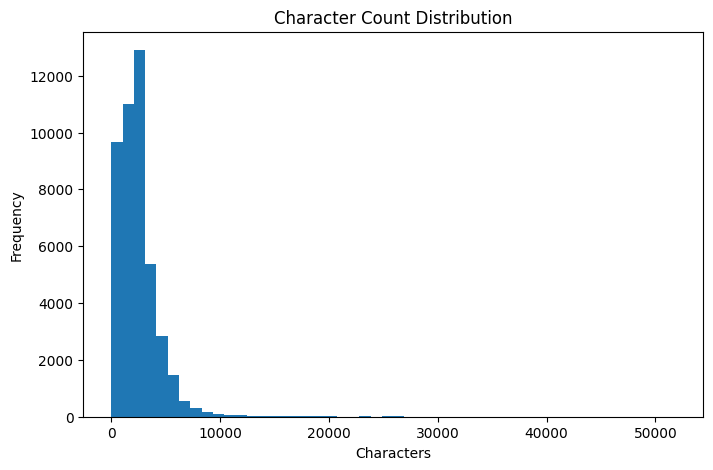

In [40]:
# Plot character count distribution

plt.figure(figsize=(8,5))

plt.hist(df["char_count"], bins=50)

plt.title("Character Count Distribution")

plt.xlabel("Characters")

plt.ylabel("Frequency")

plt.show()

In [41]:
# Compare average character count

df.groupby("label")["char_count"].mean()

,char_count
label,
0,2547.555882
1,2378.042337


In [42]:
# Load English stopwords

stop_words = stopwords.words("english")

In [43]:
# Function to clean news text

def clean_text(text):

    text = text.lower()

    text = re.sub(r"http\S+", "", text)

    text = re.sub(r"www\S+", "", text)

    text = re.sub(r"<.*?>", "", text)

    text = re.sub(r"\d+", "", text)

    text = text.translate(str.maketrans("", "", string.punctuation))

    words = text.split()

    words = [word for word in words if word not in stop_words]

    text = " ".join(words)

    return text

In [44]:
# Apply cleaning function on text column

df["text"] = df["text"].apply(clean_text)

In [45]:
# Display cleaned news text

df["text"].head()

,text
0,school librarian cambridge massachusetts rejec...
1,nairobi reuters kenyan opposition leader raila...
2,cairo reuters egypt rejected us decision move ...
3,recent speech given minister louis farrakhan t...
4,tensions ran high outside campaign rally donal...


In [46]:
# Display first news article

print(df["text"][0])

school librarian cambridge massachusetts rejected shipment books donated first lady melania trump according cbs bostonhbfamilyreading dear mrs trump reflectlibrary says thanks thanks first lady dr seuss pictwittercomtuvvwpi horn book hornbook september cbs boston wednesday reported liz phipps soeiro cambridgeport elementary school turned works trump intended sendthe white house chose one school states receive package books authored children literary author dr seussthe initiative meant promote education childhood literacy part national read book daysoeiro tuesday penned editorial horn book family reading blog explaining school need donation students access school library nine thousand volumes librarian graduate degree literary science wrote multiple studies show schools professionally staffed libraries improve student performance soeiro addedtrump package reportedly included seuss classics green eggs ham cat hat one fish two fish red fish blue fish soeiro criticized seuss author represe

In [47]:
# Display first 5 rows

df.head()

,title,text,subject,date,label,word_count,char_count
0,WOW! LEFTIST LIBRARIAN REJECTS Shipment Of Chi...,school librarian cambridge massachusetts rejec...,left-news,"Sep 28, 2017",0,1655,10062
1,Kenya opposition leader calls for calm in slum...,nairobi reuters kenyan opposition leader raila...,worldnews,"October 29, 2017",1,460,2808
2,Egypt rejects U.S. decision to move its embass...,cairo reuters egypt rejected us decision move ...,worldnews,"December 6, 2017",1,40,232
3,(AUDIO)NATION OF ISLAM LEADER FARRAKHAN: “WE W...,recent speech given minister louis farrakhan t...,left-news,"May 8, 2015",0,112,610
4,Trump Rally Nearly Turns Into A Full-Blown Ra...,tensions ran high outside campaign rally donal...,News,"March 11, 2016",0,414,2658


# **Step 7 : Feature Engineering**

In [48]:
# Calculate average word length

df["avg_word_length"] = df["char_count"] / df["word_count"]

In [49]:
# Display new features

df[["word_count","char_count","avg_word_length"]].head()

,word_count,char_count,avg_word_length
0,1655,10062,6.079758
1,460,2808,6.104348
2,40,232,5.800000
3,112,610,5.446429
4,414,2658,6.420290


In [50]:
# Check correlation between numerical features

df[["word_count","char_count","avg_word_length"]].corr()

,word_count,char_count,avg_word_length
word_count,1.000000,0.995939,-0.051990
char_count,0.995939,1.000000,-0.038988
avg_word_length,-0.051990,-0.038988,1.000000


<Axes: >

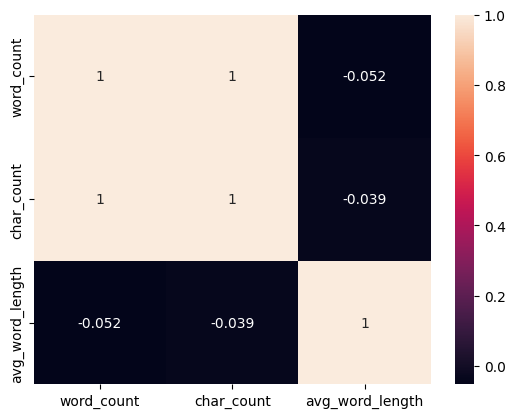

In [51]:
sns.heatmap(df[["word_count","char_count","avg_word_length"]].corr(), annot=True)

# **Step 8 : Feature Extraction (TF-IDF).**

In [52]:
# Split dataset into input and output

X = df["text"]

y = df["label"]

In [53]:
# Display first 5 news articles

X.head()

,text
0,school librarian cambridge massachusetts rejec...
1,nairobi reuters kenyan opposition leader raila...
2,cairo reuters egypt rejected us decision move ...
3,recent speech given minister louis farrakhan t...
4,tensions ran high outside campaign rally donal...


In [54]:
# Display first 5 labels

y.head()

,label
0,0
1,1
2,1
3,0
4,0


In [55]:
# Create TF-IDF vectorizer

vectorizer = TfidfVectorizer(max_features=5000)

In [56]:
# Convert text into TF-IDF features

X = vectorizer.fit_transform(X)

In [57]:
# Display shape after vectorization

X.shape

(44689, 5000)

In [58]:
# Split dataset into training and testing data

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

In [59]:
# Display training data shape

print(X_train.shape)

print(y_train.shape)

(35751, 5000)
(35751,)


In [60]:
# Display testing data shape

print(X_test.shape)

print(y_test.shape)

(8938, 5000)
(8938,)


# **Step 10 : Model Building**

In [61]:
# Import Multinomial Naive Bayes

from sklearn.naive_bayes import MultinomialNB

In [62]:
# Create Multinomial Naive Bayes model

nb_model = MultinomialNB()

In [63]:
# Train the model

nb_model.fit(X_train, y_train)

MultinomialNB()

In [64]:
# Predict on test data

nb_pred = nb_model.predict(X_test)

In [65]:
# Calculate model accuracy

nb_accuracy = accuracy_score(y_test, nb_pred)

print("Naive Bayes Accuracy :", nb_accuracy)

Naive Bayes Accuracy : 0.9487581114343253


In [66]:
# Display accuracy in percentage

print("Naive Bayes Accuracy :", round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy : 94.88 %


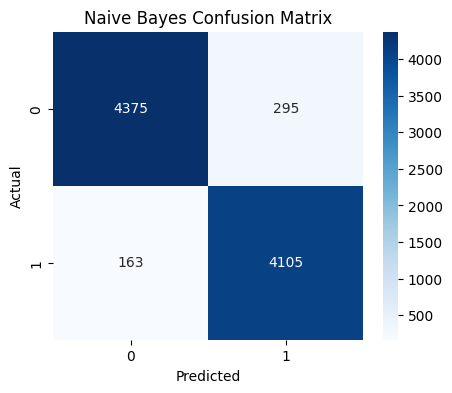

In [67]:
# Display confusion matrix

cm = confusion_matrix(y_test, nb_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [68]:
# Display classification report

print(classification_report(y_test, nb_pred))

              precision    recall  f1-score   support

           0       0.96      0.94      0.95      4670
           1       0.93      0.96      0.95      4268

    accuracy                           0.95      8938
   macro avg       0.95      0.95      0.95      8938
weighted avg       0.95      0.95      0.95      8938



# **MODEL 2 :Logistic Regression**


In [69]:
# Import Logistic Regression
from sklearn.linear_model import LogisticRegression

In [70]:
# Create Logistic Regression model

lr_model = LogisticRegression(max_iter=1000)

In [71]:
# Train the model

lr_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [72]:
# Predict on test data

lr_pred = lr_model.predict(X_test)

In [73]:
# Calculate model accuracy

lr_accuracy = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy :", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy : 98.93 %


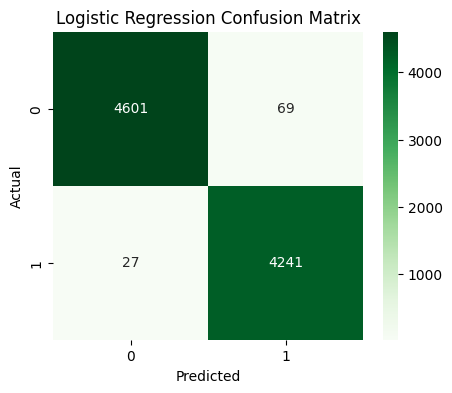

In [74]:
# Display confusion matrix

cm = confusion_matrix(y_test, lr_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Greens")

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [75]:
# Display classification report

print(classification_report(y_test, lr_pred))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99      4670
           1       0.98      0.99      0.99      4268

    accuracy                           0.99      8938
   macro avg       0.99      0.99      0.99      8938
weighted avg       0.99      0.99      0.99      8938



# **MODEL 3 :Random Forest**

In [76]:
# Import Random Forest

from sklearn.ensemble import RandomForestClassifier

In [77]:
# Create Random Forest model

rf_model = RandomForestClassifier(

    n_estimators=100,

    random_state=42

)

In [78]:
# Train the model

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [79]:
# Predict on test data

rf_pred = rf_model.predict(X_test)

In [80]:
# Calculate model accuracy

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy :", round(rf_accuracy * 100, 2), "%")

Random Forest Accuracy : 99.7 %


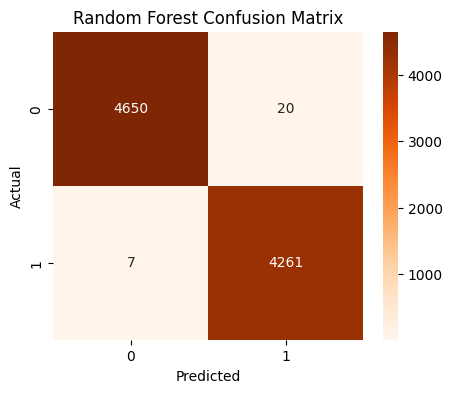

In [81]:
# Display confusion matrix

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(5,4))

sns.heatmap(cm, annot=True, fmt="d", cmap="Oranges")

plt.title("Random Forest Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [82]:
# Display classification report

print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00      4670
           1       1.00      1.00      1.00      4268

    accuracy                           1.00      8938
   macro avg       1.00      1.00      1.00      8938
weighted avg       1.00      1.00      1.00      8938



# **Step 11 : Compare Model Accuracy**


In [83]:
# Compare accuracy of all models

accuracy = pd.DataFrame({

    "Model": [

        "Multinomial Naive Bayes",

        "Logistic Regression",

        "Random Forest"

    ],

    "Accuracy": [

        nb_accuracy,

        lr_accuracy,

        rf_accuracy

    ]

})

accuracy

,Model,Accuracy
0,Multinomial Naive Bayes,0.948758
1,Logistic Regression,0.989259
2,Random Forest,0.996979


In [84]:
# Convert accuracy into percentage

accuracy["Accuracy"] = accuracy["Accuracy"] * 100

accuracy

,Model,Accuracy
0,Multinomial Naive Bayes,94.875811
1,Logistic Regression,98.925934
2,Random Forest,99.697919


In [85]:
# Display best model

best_model = accuracy.loc[accuracy["Accuracy"].idxmax()]

print(best_model)

Model       Random Forest
Accuracy        99.697919
Name: 2, dtype: object


# **Step 12 : Fake News Prediction**



In [89]:
# Function to predict fake or real news

def predict_news(news):

    news = clean_text(news)

    news = vectorizer.transform([news])

    prediction = rf_model.predict(news)

    if prediction[0] == 0:

        return "Fake News"

    else:

        return "Real News"

In [90]:
# Take news from user

news = input("Enter News : ")

Enter News : Aliens officially became the new rulers of Earth after signing a peace treaty with all world governments.


In [91]:
# Predict the result

result = predict_news(news)

print("\nPrediction :", result)


Prediction : Fake News


In [92]:
# Save the trained model

import pickle

pickle.dump(rf_model, open("fake_news_model.pkl", "wb"))

pickle.dump(vectorizer, open("tfidf_vectorizer.pkl", "wb"))

print("Model saved successfully.")

Model saved successfully.
